# Goal:
Train different tokenizers from scratch and use a constant transformer (one we built or used) 

### What we should do:
- load a dataset OR we can load several datasets (english/russian/japanese/romanian)
- for each tokenization strategy train tokenizer from scratch:
    -- BPE using tokenizers or SentencePiece
    -- Unigram using SentencePiece
    -- byte-level tokenizers via tokenizers.ByteLevelBPETokenizer or raw byte encoding
    -- pretrained tiktokenizer for gpt-4o as a benchmark 
- build small identical model for each tokenizer
    -- small transformer instead of an RNN (embedding -> transformer blocks (2-4 layers) -> LM head )
    -- each model is reinitialised from scratch for each tokenizer
- train model for a fixed number of steps or compute cost - maybe for the throughput of bits or characters
- compare results based on
    -- perplexity / validation loss (generalization)
    -- efficiency (training speed, tokens/sec, ect)
    -- tokenization-independent metrics (byte-per-character, embedding parameter size)

Perplexity - how well  model predicts the next token = e^(cross-entropy loss). To measure the perplexity across different tokenizers with different strategies, we need to normalize them (because different size of tokens etc.). To do that ,we use the BPC (bits per character) = loss(in nats)/ ln(2) * tokens/characters.

### A Minimal Set of Metrics to Compute


| Category   | Metric                                  |
| ---------- | --------------------------------------- |
| Quality    | Perplexity, Val loss                    |
| Efficiency | tokens/char, compression ratio          |
| Cost       | seq length vs FLOPs                     |
| Semantics  | clustering consistency, downstream task |
| Robustness | OOV rate, cross-domain perplexity       |
| Storage    | vocab size, embedding params            |


## Set of Metrics we want to analyze

| Category                    | Metric                                   | Explanation                                                                                                                                                                       |
| --------------------------- | ---------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Quality**                 | **(1) Validation Loss**                  | Cross-entropy loss on held-out data. Shows how well the model generalizes with a given tokenizer. Lower = better.                                                                 |
|                             | **(2) Bits-Per-Character (BPC)**         | Normalizes loss across different tokenizers by converting token-level loss into a per-character measure. Lets you fairly compare BPE vs Unigram vs Byte-Level. Lower = better.    |
| **Tokenization Efficiency** | **(3) Tokens / Character**               | Measures how many tokens are needed to represent one character of text. Lower = more compression → shorter sequences.                                                             |
|                             | **(4) Average Characters / Token**       | Measures typical token length. High values mean the tokenizer creates larger subwords; low values mean it fragments words more.                                                   |
| **Compute Cost**            | **(5) Sequence Length Distribution**     | Shows how long tokenized sequences are (mean, variance). Important because transformer cost grows quadratically with sequence length.                                             |
|                             | **(6) Training Throughput (tokens/sec)** | How many tokens the model processes per second during training. Proxy for training speed and compute efficiency. Higher = cheaper/faster training.                                |
| **Robustness**              | **(7) OOV Rate (Out-Of-Vocabulary)**     | Percentage of text that can’t be represented directly and falls back to `<unk>` or byte decomposition. Lower = better coverage of real language.                                  |
|                             | **(8) Unicode / Character Coverage**     | Measures how well the tokenizer can handle diverse characters (e.g., Cyrillic, Latin, punctuation, emojis). Higher coverage = better generalization across languages and domains. |
| **Storage**                 | **(9) Embedding Parameter Count**        | Total number of parameters in the embedding matrix (vocab_size × embedding_dim). Dictates memory footprint and part of model size.                                                |
                                                                                |


### Tokenizer-only metrics
| Metric                               | Category     | Why tokenizer-only?                                       |
| ------------------------------------ | ------------ | --------------------------------------------------------- |
| **(3) Tokens / Character**           | Efficiency   | Pure tokenization behavior.                               |
| **(4) Average Characters / Token**   | Efficiency   | Depends only on segmentation.                             |
| **(5) Sequence Length Distribution** | Compute cost | Sequence length is produced by tokenizer before training. |
| **(7) OOV Rate**                     | Robustness   | Tokenizer’s ability to cover text.                        |
| **(8) Unicode / Character Coverage** | Robustness   | Tokenizer’s vocabulary coverage of character set.         |
| **(10) Vocab File Size**             | Storage      | Pure tokenizer metadata.                                  |


### Tokenizer+Model metrics

| Metric                                   | Category     | Explanation                                                                                                 |
| ---------------------------------------- | ------------ | ----------------------------------------------------------------------------------------------------------- |
| **(1) Validation Loss**                  | Quality      | Loss is computed over model output → but depends on tokenization.                                           |
| **(2) Bits-Per-Character (BPC)**         | Quality      | Uses both: tokenizer → tokens; model → loss.                                                                |
| **(6) Training Throughput (tokens/sec)** | Compute cost | Throughput depends on sequence lengths created by tokenizer *and* training config (batch size, model size). |
| **(9) Embedding Parameter Count**        | Storage      | Depends on tokenizer’s `vocab_size` and model’s `embedding_dim`.                                            |



## Import text dataset

Our goal is to have a text dataset of two languages. The proportion of lanugaes should eb 50/50. Morevoer, we think it is interesting to investigate how a tokenizer and a model using it would perform on different alphabets. For that purpose, we decided to choose the latin and cyrilic alphabets. As for languages, it is English (that we all speak and can thus evaluate) and Russian (that one of the group members knows). This small research will show us what happens when combining two alphabets that are smewhat similar (not like latin and kanji for example), but still have different charaters.   
We are taking 5 million characters per each language - this is our dataset limit. 

In [1]:
# -----------------------------------------------------------------------------
#                               Load Dataset
# -----------------------------------------------------------------------------

from datasets import load_dataset


def load_wikipedia_text(language, target_chars):
    dataset = load_dataset(
        "wikimedia/wikipedia",
        f"20231101.{language}",
        split="train",
        # trust_remote_code=True,
        
        # uncomment this line to save to $BLACKHOLE in HPC
        cache_dir="/dtu/blackhole/00/223200"
    )

    texts = []
    chars_collected = 0

    for row in dataset:
        article = row["text"]
        article_len = len(article)

        if chars_collected + article_len <= target_chars:
            texts.append(article)
            chars_collected += article_len
        else:
            # Only take the portion we need to reach the target
            remaining = target_chars - chars_collected
            texts.append(article[:remaining])
            chars_collected += remaining
            break

    print(f"{language}: collected {chars_collected:,} characters from {len(texts):,} articles")
    return texts


# https://arxiv.org/pdf/2203.15556#page=24.27  in this paper they set the ratio for optimal language model training to 20 tokens per trainable parameter

trainable_params = 2_215_552  # number of trainable parameters in our model when using vocab size of 16000
# trainable_params = 6_558_805  # number of trainable parameters in our model when using vocab size of 50000 and 256 SEQ_LEN--- way too much
trainable_params = 4_236_805  # number of trainable parameters in our model when using vocab size of 32000 and 256 SEQ_LEN
trainable_params = 2688805  # number of trainable parameters in our model when using vocab size of 20000 and 128 SEQ_LEN
trainable_params = 3333805  # number of trainable parameters in our model when using vocab size of 25000 and 128 SEQ_LEN
# trainable_params = 6_558_805
# trainable_params = 4236805
trainable_params = 2688805

# FIXME: the target does not take into account the 70/10/20 split between train/val/test
TARGET = trainable_params * 20  # target number of characters to load; we fix this for all other experiments


# TODO: make this multilingual again, doesn't work in my HPC environment for some reason
text_en = load_wikipedia_text("en", TARGET)
text_ru = load_wikipedia_text("ru", TARGET)
text =  text_ru + text_en
## thank you Oskar


ModuleNotFoundError: No module named 'datasets'

In [2]:
print(text_ru[0][:500])


Литва́ ( ), официальное название — Лито́вская Респу́блика () — государство, расположенное в Северной Европе. Площадь —  км². Протяжённость с севера на юг — 280 км, а с запада на восток — 370 км. Население составляет  человек (август, 2023). Занимает 137-е место в мире по численности населения и 121-е по территории. Имеет выход к Балтийскому морю, расположена на его восточном побережье. Береговая линия составляет всего 99 км (наименьший показатель среди государств Балтии). На севере граничит с Ла


# Training different Tokenizers

## BPE tokenizer
### This version does not encode the russian characters correctly!

| Use Unicode BPE when                  | Use Byte-Level BPE when                   |
| ------------------------------------- | ----------------------------------------- |
| You want meaningful tokens            | You want 100% reversible encoding         |
| Languages are well-formed text        | You need arbitrary byte support           |
| Training multilingual language models | You're mimicking GPT-2 or RoBERTa         |
| You care about linguistic structure   | You care about robustness over structure  |
| Data is clean Unicode                 | Data may contain noise or mixed encodings |


| Feature               | BPE                                    | Byte-Level BPE    | Unigram                     |
| --------------------- | -------------------------------------- | ----------------- | --------------------------- |
| Based on              | merging pairs                          | merging bytes     | removing worst tokens       |
| Works on              | chars                                  | bytes             | chars                       |
| Handles unknown chars | requires `<unk>`                       | no `<unk>` needed | requires `<unk>`            |
| Good for multilingual | decent                                 | robust but noisy  | excellent                   |
| Output stability      | deterministic                          | deterministic     | probabilistic, can resample |
| Best use case         | GPT-like models? No, GPT uses byte-BPE | GPT style         | T5/LLaMA/RNN hybrid LMs     |


In [4]:
from tokenizers import Tokenizer
from tokenizers.models import BPE, WordPiece, Unigram
from tokenizers.pre_tokenizers import BertPreTokenizer, Metaspace, ByteLevel
from tokenizers.trainers import BpeTrainer, WordPieceTrainer, UnigramTrainer
from pathlib import Path
from typing import List, Literal, Optional
import string
from tokenizers.processors import ByteLevel as ByteLevelProcessor
from tokenizers.normalizers import Sequence, NFKC
from pathlib import Path
from typing import List, Literal, Optional
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from tokenizers.models import Unigram
from tokenizers.trainers import UnigramTrainer
import time

In [3]:
# ---------------------------------------------------------------------
#                              Tokenizers
# ---------------------------------------------------------------------

TokenizerModel = Literal["bpe", "wordpiece", "unigram", "bytelevel"]

def train_custom_tokenizer(
    texts: List[str], 
    model_type: TokenizerModel, 
    vocab_size: int, 
    min_frequency: int = 2,
    special_tokens: Optional[List[str]] = None,
    save_path: str = "tokenizers/custom_tokenizer.json",
):

    if special_tokens is None:
        special_tokens = [ "[UNK]", "[EOS]"]


    print(f"Training {model_type.upper()} tokenizer...")

    # --------------------------
    # Normal BPE (Unicode tokens)
    # --------------------------
    if model_type == "bpe":
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.normalizer = Sequence([NFKC()])
        tokenizer.pre_tokenizer = BertPreTokenizer()

        trainer = BpeTrainer(
            vocab_size=vocab_size,
            min_frequency=min_frequency,
            special_tokens=special_tokens,
        )

    # --------------------------
    # BYTE-LEVEL BPE  Tokenizer
    # --------------------------
    # here we observe issues with encoding decoding the russina text
    # uses raw utf-8 bytes and merges are applied to byte sequences, not charcaters like before. Generally, this is used to avoud UNK characters
    # the issue with russian tokens is the pre-processing and post-processing, and the fact that on reconstruction, so garbage characters are formmed. 
    # Пр → corrupted → ÐŁÑĢ
    
    elif model_type == "bytelevel":
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))

        # must operate on bytes BEFORE unicode interpretation
        tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=True)

        tokenizer.normalizer = None

        ## must be used for proper decoding back into russian characters
        tokenizer.decoder = ByteLevelDecoder()

        # must reconstruct bytes AFTER merging
        tokenizer.post_processor = ByteLevelProcessor()

        trainer = BpeTrainer(
            vocab_size=vocab_size,
            special_tokens=special_tokens
        )
    # --------------------------
    #     Unigram Tokenizer
    # --------------------------
    elif model_type == "unigram":
        tokenizer = Tokenizer(Unigram())
        
        tokenizer.normalizer = Sequence([NFKC()]) 
        tokenizer.pre_tokenizer = BertPreTokenizer()
        
        trainer = UnigramTrainer(
            vocab_size=vocab_size,
            special_tokens=special_tokens,
            unk_token="[UNK]"
        )

    # --------------------------
    #    Wordpiece Tokenizer
    # --------------------------
    elif model_type == "wordpiece":
        tokenizer = Tokenizer(WordPiece(unk_token="[UNK]"))

        tokenizer.normalizer = Sequence([NFKC()])
        tokenizer.pre_tokenizer = BertPreTokenizer()

        trainer = WordPieceTrainer(
            vocab_size=vocab_size,
            min_frequency=min_frequency,
            special_tokens=special_tokens,
        )

    # --------------------------
    #       Else error ...
    # --------------------------
    else:
        raise ValueError(f"Unknown model type: {model_type}")



    # Train tokenizer
    tokenizer.train_from_iterator(texts, trainer)

    # Save
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    tokenizer.save(str(save_path))

    print(f"{model_type.upper()} tokenizer trained and saved to {save_path}")
    return tokenizer# https://arxiv.org/pdf/1909.03341 
# Expected output: ... Tokens will be segments of the base character set, often starting with 'G' or similar for spaces.

## Custom Tokenizer

### Set Final Tokenizer:

In [ ]:
from tokenizers.processors import ByteLevel as ByteLevelProcessor
from tokenizers.normalizers import Sequence, NFKC
from collections import Counter
import numpy as np
import os
from pathlib import Path

bytelevel_tokenizer = train_custom_tokenizer(
    texts=text,
    model_type="bytelevel",
    vocab_size=20000, ##16k - 32k should be fine.  between 32 - 50 k for bilingual
)

bpe_tokenizer = train_custom_tokenizer(
    texts=text,
    model_type="bpe",
    vocab_size=20000, ##16k - 32k should be fine.  between 32 - 50 k for bilingual
)

unigram_tokenizer = train_custom_tokenizer(
    texts=text,
    model_type="unigram",
    vocab_size=20000, ##16k - 32k should be fine.  between 32 - 50 k for bilingual
)

wordpiece_tokenizer = train_custom_tokenizer(
    texts=text,
    model_type="wordpiece",
    vocab_size=20000, ##16k - 32k should be fine.  between 32 - 50 k for bilingual
)

# ByteLevel output will show tokens composed of the base characters/bytes
# print(f"\nByteLevel Tokenization Example: {bytelevel_tokenizer.encode('handles all unicode').tokens}")
# print(f"\BPE Tokenization Example: {bpe_tokenizer.encode('handles all unicode').tokens}")
# print(f"\Unigram Tokenization Example: {unigram_tokenizer.encode('handles all unicode').tokens}")
# print(f"\Wordpiece Tokenization Example: {wordpiece_tokenizer.encode('handles all unicode').tokens}")


Training BYTELEVEL tokenizer...
BYTELEVEL tokenizer trained and saved to tokenizers\custom_tokenizer.json


### Tokens per Character

In [5]:
def tokens_per_character(tokenizer, texts):
    total_tokens = 0
    total_chars = 0

    for t in texts:
        enc = tokenizer.encode(t)
        total_tokens += len(enc.ids)
        total_chars  += len(t)

    value = total_tokens / max(total_chars, 1)
    print(f"[Tokens/Character] {value:.4f}")
    return value


### Average Characters Per Token

In [6]:
def avg_characters_per_token(tokenizer, texts):
    total_chars = 0
    total_tokens = 0

    for t in texts:
        enc = tokenizer.encode(t)
        tokens = enc.tokens
        total_tokens += len(tokens)
        total_chars  += sum(len(tok) for tok in tokens)

    value = total_chars / max(total_tokens, 1)
    print(f"[Avg Characters/Token] {value:.4f}")
    return value


### Sequence Length Distribution

In [7]:
def sequence_length_distribution(tokenizer, texts, seq_len=128):
    lengths = []

    for t in texts:
        enc = tokenizer.encode(t)
        lengths.append(len(enc.ids))

    lengths = np.array(lengths)

    print(f"[Sequence Length Distribution]")
    print(f"  mean: {lengths.mean():.2f}")
    print(f"  std:  {lengths.std():.2f}")
    print(f"  min:  {lengths.min():.2f}")
    print(f"  max:  {lengths.max():.2f}")
    return lengths


### OOV Rate

In [8]:
def oov_rate(tokenizer, texts):
    unk_id = tokenizer.token_to_id("[UNK]")
    if unk_id is None:
        print("[OOV Rate] this tokenizer has no [UNK] token")
        return 0.0
    
    total_tokens = 0
    unk_tokens = 0

    for t in texts:
        enc = tokenizer.encode(t)
        ids = enc.ids

        total_tokens += len(ids)
        unk_tokens   += sum(1 for i in ids if i == unk_id)

    value = unk_tokens / max(total_tokens, 1)
    print(f"[OOV Rate] {value:.5f}")
    return value


### Unicode / Character Coverage

In [9]:
def unicode_character_coverage(tokenizer, texts):
    """Percentage of UNIQUE characters for which tokenizer never produces UNK."""
    all_chars = set("".join(texts))
    covered_chars = 0

    for ch in all_chars:
        enc = tokenizer.encode(ch)
        ids = enc.ids
        # If encoding the char results in UNK → not covered
        if all(token_id != tokenizer.token_to_id("[UNK]") for token_id in ids):
            covered_chars += 1

    value = covered_chars / max(len(all_chars), 1)
    print(f"[Unicode Coverage] {value*100:.2f}%")
    return value



### Bytelevel Tokenizer results

In [10]:
test = "Привет, как дела?"
ids = bytelevel_tokenizer.encode(test).ids
print(ids)

decoded = bytelevel_tokenizer.decode(ids)
print(decoded)


bytelevel_tokens_per_char = tokens_per_character(bytelevel_tokenizer, text)
bytelevel_avg_characters_per_token = avg_characters_per_token(bytelevel_tokenizer, text)
# sequence_length_distribution(bytelevel_tokenizer, text)
# oov_rate(bytelevel_tokenizer, text)
# unicode_character_coverage(bytelevel_tokenizer, text)

[1859, 1321, 13, 737, 4368, 32]
 Привет, как дела?
[Tokens/Character] 0.2684
[Avg Characters/Token] 5.2164


### BPE Tokenizer results

In [ ]:
import time

test = "Привет, как дела?"
ids = bpe_tokenizer.encode(test).ids
print(ids)

decoded = bpe_tokenizer.decode(ids)
print(decoded)

started = time.time()

bpe_tokens_per_char = tokens_per_character(bpe_tokenizer, text)
bpe_avg_characters_per_token = avg_characters_per_token(bpe_tokenizer, text)
# sequence_length_distribution(bpe_tokenizer, text)
# oov_rate(bpe_tokenizer, text)
# unicode_character_coverage(bpe_tokenizer, text)

ended = time.time()
print(f"Time spent: {ended - started:.4f} seconds")

### Unigram Tokenizer results

In [ ]:
test = "Привет, как дела?"
ids = unigram_tokenizer.encode(test).ids
print(ids)

decoded = unigram_tokenizer.decode(ids)
print(decoded)

started = time.time()

unigram_tokens_per_char = tokens_per_character(unigram_tokenizer, text)
unigram_avg_characters_per_token = avg_characters_per_token(unigram_tokenizer, text)
# sequence_length_distribution(unigram_tokenizer, text)
# oov_rate(unigram_tokenizer, text)
# unicode_character_coverage(unigram_tokenizer, text)

ended = time.time()
print(f"Time spent: {ended - started:.4f} seconds")


### Wordpiece Tokenizer results


In [ ]:
test = "Привет, как дела?"
ids = wordpiece_tokenizer.encode(test).ids
print(ids)

decoded = wordpiece_tokenizer.decode(ids)
print(decoded)

started = time.time()

wordpiece_tokens_per_char = tokens_per_character(wordpiece_tokenizer, text)
wordpiece_avg_characters_per_token = avg_characters_per_token(wordpiece_tokenizer, text)
# sequence_length_distribution(wordpiece_tokenizer, text)
# oov_rate(wordpiece_tokenizer, text)
# unicode_character_coverage(wordpiece_tokenizer, text)

ended = time.time()
print(f"Time spent: {ended - started:.4f} seconds")


### Helper Class for Handling Tokenizers


In [ ]:
from typing import List, Iterable
import torch
from torch.utils.data import Dataset, DataLoader

## converts long list of token ids into many small overlapping training samples for next-token language model
## produces sliding windows of seq_len size
## input x are token sequences
## outputs y are the same sequences shifted by one position - meaning predict the next token
## this way, the model learns - given the sequence, what comes next?
class NextTokenDataset(Dataset):
    def __init__(self, token_ids: List[int], seq_len: int, pad_id: int, stride:int):
        self.ids = token_ids
        self.seq_len = seq_len
        self.pad_id = pad_id

        # Number of training examples (each is a sliding window of length seq_len)
        # self.n = max(0, len(self.ids) - self.seq_len)
        self.stride = stride
        # self.stride = 1

        max_start = len(self.ids) - seq_len - 1  # -1 because y starts at start+1
        if max_start <= 0:
            self.starts = []
        else:
            self.starts = list(range(0, max_start + 1, stride))

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        start = self.starts[idx]
        x = self.ids[start:start + self.seq_len]
        y = self.ids[start + 1:start + 1 + self.seq_len]

        x = torch.tensor(x, dtype=torch.long)
        y = torch.tensor(y, dtype=torch.long)
        return x, y

def encode_corpus(tokenizer, texts: Iterable[str]) -> List[int]:
    """Concatenate all article token-ids into one long stream."""
    all_ids: List[int] = []

    # Define a valid separator token ID
    sep_id = tokenizer.token_to_id("[EOS]")


    for t in texts:
        try:
            enc = tokenizer.encode(t)
            ids = enc.ids if hasattr(enc, "ids") else enc  # handle different API types
            all_ids.extend(ids)
            all_ids.append(sep_id)  # separator for stability
        except Exception as e:
            # If something fails (bad text, unknown chars), skip that article
            print(f"Skipped an article due to encoding error: {e}")
            continue

    # Final safety check — all IDs must be < vocab_size
    vocab_size = tokenizer.get_vocab_size()
    before_count = len(all_ids)
    
    # all_ids = [i for i in all_ids if isinstance(i, int) and 0 <= i < vocab_size]

    if len(all_ids) < before_count:
        print(f"Removed {before_count - len(all_ids)} invalid token IDs from corpus")

    print(f"Encoded {len(texts)} texts into {len(all_ids)} token IDs")
    print(f"Vocabulary size: {vocab_size}")
    return all_ids


# use 70% train, 10% val, 20% test split
def make_dataloaders(token_ids: List[int], seq_len=256, batch_size=32, pad_id=0, stride=None):

    if stride is None:
        stride = seq_len

    n = len(token_ids) 
    train_end = int(n * 0.7)
    val_end = train_end + int(n * 0.1)

    train_ids = token_ids[:train_end]
    val_ids   = token_ids[train_end:val_end]
    test_ids  = token_ids[val_end:]

    train_ds = NextTokenDataset(train_ids, seq_len=seq_len, pad_id=pad_id, stride=stride)
    val_ds   = NextTokenDataset(val_ids,   seq_len=seq_len, pad_id=pad_id,  stride=stride)
    test_ds  = NextTokenDataset(test_ids,   seq_len=seq_len, pad_id=pad_id, stride=stride)


    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=True, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=True, num_workers=0)
    return train_loader, val_loader, test_loader


## Unified Model That is Used in Combination with Tokenizers

In [12]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
# -----------------------------------------------------
#         Model with transformer architecture
# -----------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class TransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=2, num_layers=2, dim_feedforward=256, dropout=0.1, max_seq_length=128): # max_seq_length needs to be >= your seq_len
        super().__init__()
        self.model_type = "Transformer"
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_seq_len = max_seq_length

        # token IDs ---> vectors
        # ---------------------------
        # Token + position embeddings
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_length, d_model)

        # ---------------------------
        #    Transformer encoder 
        # ---------------------------
        # (Batch, T: sequence length at batch step, C: channels))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, # dimentionality of input embeddings
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,    # match (batch, seq_len, d_model)...here for now (64, 10, 128)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # vectors --> logits 
        # ---------------------------
        # Final linear layer to vocab logits
        self.decoder = nn.Linear(d_model, vocab_size)

        self.register_buffer("causal_mask", self._generate_causal_mask(max_seq_length, device=device))

        self._reset_parameters()

    # initialize parameters of the Transformer --> random weights
    # ---------------------------
    def _reset_parameters(self):
        initrange = 0.1
        nn.init.uniform_(self.tok_emb.weight, -initrange, initrange)
        nn.init.uniform_(self.pos_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    # Mask to prevent attention to future tokens
    # ---------------------------
    def _generate_causal_mask(self, seq_length, device):
        # Shape: (T, T) with -inf above diagonal
        mask = torch.triu(torch.ones(seq_length, seq_length, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask

    def forward(self, src):
            """
            src: LongTensor of shape (batch_size, seq_len)
            returns: logits of shape (batch_size, seq_len, vocab_size)
            """
            batch_size, seq_len = src.shape
            device = src.device

            # Token + positional embeddings
            tok_emb = self.tok_emb(src) * math.sqrt(self.d_model)   # (B, T, C)

            # Position ids: [0, 1, ..., seq_len-1]
            pos_ids = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, seq_len)
            pos_emb = self.pos_emb(pos_ids)                         # (B, T, C)

            x = tok_emb + pos_emb                                   # (B, T, C)

            # Causal mask so token t can't see future tokens > t
            # src_mask = self._generate_causal_mask(seq_len, device)  # (T, T)
            src_mask = self.causal_mask[:seq_len, :seq_len] ## to avoid regenerating masks multiuple times per epoch

            # Transformer encoder
            x = self.transformer_encoder(x, mask=src_mask)          # (B, T, C)

            # Project to vocabulary
            logits = self.decoder(x)                                # (B, T, vocab_size)
            return logits
    
    # Text generating Function
    # ---------------------------
    def sample(self, batch_size=1, num_steps=30, temperature=1.0, start_tokens=None, device=None):
        """
        Autoregressively sample tokens from the model.

        Returns: LongTensor of shape (batch_size, initial_len + num_steps)
        """
        # if device is not specified, use the device of the model parameters (CUDA or MPS)
        if device is None:
            device = next(self.parameters()).device

        # if no starting tokens are provided, start with a dummy token
        if start_tokens is None:
            # Start with a single dummy token (e.g. token id 0)
            x = torch.zeros(batch_size, 1, dtype=torch.long, device=device)
        # else, use the provided starting tokens
        else:
            x = start_tokens.to(device)
            if x.dim() == 1:
                x = x.unsqueeze(0).expand(batch_size, -1)  # (B, T0)

        # each loop appends one token
        for _ in range(num_steps):
            # get the logits for the current sequence, returns a probability distribution over the vocabulary at each position
            logits = self(x)                   # (B, T, V)
            logits_last = logits[:, -1, :]     # (B, V) – last time step

            # apply temperature
            logits_last = logits_last / temperature
            # convert logits to probabilities
            probs = F.softmax(logits_last, dim=-1)

            # randomly picks a token ID based on the probabilities
            next_token = torch.multinomial(probs, num_samples=1)  # (B, 1)
            # append the predicted token to the sequence
            x = torch.cat([x, next_token], dim=1)

            # Keep the sequence from getting too long
            if x.size(1) > self.max_seq_len:
                x = x[:, -self.max_seq_len:]

        # returns the generated sequences
        return x



Using device: cuda


## Training

In [17]:
# 1) Encode entire corpus
bytelevel_token_ids = encode_corpus(bytelevel_tokenizer, text)
bytelevel_token_ids_length = len(bytelevel_token_ids)
print("Total tokens in corpus:", len(bytelevel_token_ids))

Encoded 6868 texts into 28868583 token IDs
Vocabulary size: 20000
Total tokens in corpus: 28868583


In [ ]:
# 1) Encode entire corpus
bpe_token_ids = encode_corpus(bpe_tokenizer, text)
bpe_token_ids_length = len(bpe_token_ids)
print("Total tokens in corpus:", len(bpe_token_ids))

In [ ]:
# 1) Encode entire corpus
unigram_token_ids = encode_corpus(unigram_tokenizer, text)
unigram_token_ids_length = len(unigram_token_ids)
print("Total tokens in corpus:", len(unigram_token_ids))

In [ ]:
# 1) Encode entire corpus
wordpiece_token_ids = encode_corpus(wordpiece_tokenizer, text)
wordpiece_token_ids_length = len(wordpiece_token_ids)
print("Total tokens in corpus:", len(wordpiece_token_ids))

In [40]:
# hyperparameters
SEQ_LEN = 128 ## this should be fine for this course. 64-128 for smaller projects. 512-1024 for much bigger models
BATCH_SIZE = 32 ## go to 16-32 of we get gpu out of memory and the seq size is bigger
LEARNING_RATE = 1e-4
# LEARNING_RATE = 0.001
NUM_EPOCHS = 50

In [ ]:
# MAX_TOKENS = 50_000  
# bytelevel_corpus_len = min(len(bytelevel_token_ids), MAX_TOKENS)
bytelevel_corpus_len = int(bytelevel_token_ids_length/10)
print("Bytelevel corpus len:", bytelevel_corpus_len)
bpe_corpus_len = int(bpe_token_ids_length/10)
unigram_corpus_len = int(unigram_token_ids_length/10)
wordpiece_corpus_len = int(wordpiece_token_ids_length/10)
# 2) Dataloaders
# pad_id = tokenizer.token_to_id("[PAD]") or 0
# [:SEQ_LEN*128] is just a small subset for quick testing
# train_loader, val_loader, test_loader = make_dataloaders(token_ids[:SEQ_LEN*128], seq_len=SEQ_LEN, batch_size=BATCH_SIZE, pad_id=pad_id)
bytelevel_train_loader, bytelevel_val_loader, bytelevel_test_loader = make_dataloaders(bytelevel_token_ids[:bytelevel_corpus_len], seq_len=SEQ_LEN, batch_size=BATCH_SIZE, stride=32)
print("Bytelevel:")
print(f"Train batches: {len(bytelevel_train_loader)}, Val batches: {len(bytelevel_val_loader)}, Test batches: {len(bytelevel_test_loader)}")

print("BPE:")
bpe_train_loader, bpe_val_loader, bpe_test_loader = make_dataloaders(bpe_token_ids[:bpe_corpus_len], seq_len=SEQ_LEN, batch_size=BATCH_SIZE)
print(f"Train batches: {len(bpe_train_loader)}, Val batches: {len(bpe_val_loader)}, Test batches: {len(bpe_test_loader)}")

print("Unigram:")
unigram_train_loader, unigram_val_loader, unigram_test_loader = make_dataloaders(unigram_token_ids[:unigram_corpus_len], seq_len=SEQ_LEN, batch_size=BATCH_SIZE)
print(f"Train batches: {len(unigram_train_loader)}, Val batches: {len(unigram_val_loader)}, Test batches: {len(unigram_test_loader)}")

print("Wordpiece:")
wordpiece_train_loader, wordpiece_val_loader, wordpiece_test_loader = make_dataloaders(wordpiece_token_ids[:wordpiece_corpus_len], seq_len=SEQ_LEN, batch_size=BATCH_SIZE)
print(f"Train batches: {len(wordpiece_train_loader)}, Val batches: {len(wordpiece_val_loader)}, Test batches: {len(wordpiece_test_loader)}")

Bytelevel corpus len: 2886858
Bytelevel:
Train batches: 1973, Val batches: 281, Test batches: 563


#### Full batch sizes:
Bytelevel:
Train batches: 315748, Val batches: 45105, Test batches: 90212

BPE:
Train batches: 296459, Val batches: 42349, Test batches: 84701

Unigram:
Train batches: 316417, Val batches: 45200, Test batches: 90403

Wordpiece:
Train batches: 307118, Val batches: 43872, Test batches: 87746

### Training & Evaluation

In [43]:
import torch
from torch.amp import autocast, GradScaler

@torch.no_grad() # Crucial: Disables gradient calculation, significantly speeding up evaluation
def evaluate(model, loader, criterion, device):
    """Calculates the average loss across the entire dataset in the provided loader."""
    model.eval() # Set the model to evaluation mode
    total_loss = 0.0
    total_batches = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        total_loss += loss.item()
        total_batches += 1

    model.train() # Set the model back to training mode
    return total_loss / total_batches

###
# tokens_per_char come from the individual tokenizers from above
###

def train_model(tokenizer, train_loader, val_loader, tokens_per_char):
    # 3) Model Initialization
    # Ensure SEQ_LEN, LEARNING_RATE, NUM_EPOCHS, and TransformerLM are accessible globally or defined.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    vocab_size = tokenizer.get_vocab_size()

    # Assuming TransformerLM is a class that takes these arguments
    model = TransformerLM(vocab_size=vocab_size, max_seq_length=SEQ_LEN).to(device)

    # New: Compile the model!
    # if device.type == 'cuda':
    #     model = torch.compile(model) 
    #     print("Model compiled with torch.compile() for speedup.")

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Trainable parameters:", trainable_params)
    print(f"Number of model parameters: {trainable_params:,}")

    # 4) Optim & loss
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.1)
    criterion = torch.nn.CrossEntropyLoss()

    # New: Initialize Gradient Scaler for AMP
    # scaler = GradScaler(enabled=(device.type == 'cuda'))

    # Metrics storage
    history = {"train_loss": [], "val_loss": [], "ppl": []}
    throughput_per_epoch = {}

    num_batches = len(train_loader)
    print("Num batches:", num_batches)

    # 5) Train epochs
    for epoch in range(NUM_EPOCHS):
        start = time.time()

        model.train() # Set model to training mode
        print(f"Epoch {epoch} trained.")
        
        # --- TRAINING PASS (Optimized: Incremental Loss Calculation) ---
        epoch_train_loss = 0.0
        batch_times = []
        
        for batch_idx, (x, y) in enumerate(train_loader):
            batch_start_time = time.time() # Start timing for ETA
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))

            # Backprop
            loss.backward()
            optimizer.step()

            # Incremental loss tracking
            epoch_train_loss += loss.item()

            batch_end_time = time.time() # End timing for ETA
            batch_times.append(batch_end_time - batch_start_time)

            # --- PROGRESS AND ETA PRINTING ---
            if batch_idx % 10 == 0 or batch_idx == num_batches - 1:
                if batch_idx >= 4:
                    # Calculate average time per batch based on recorded times
                    avg_time_per_batch = np.mean(batch_times)
                    
                    # Estimate remaining time
                    batches_remaining = num_batches - (batch_idx + 1)
                    eta_seconds = avg_time_per_batch * batches_remaining
                    
                    # Convert ETA to H:M:S format
                    m, s = divmod(int(eta_seconds), 60)
                    h, m = divmod(m, 60)
                    eta_str = f"{h:d}:{m:02d}:{s:02d}"
                else:
                    eta_str = "Calculating..."
                
                print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Batch {batch_idx + 1}/{num_batches} | Loss: {loss.item():.4f} | ETA: {eta_str}")

        # Calculate average training loss for the epoch
        avg_train_loss = epoch_train_loss / num_batches
        history["train_loss"].append(avg_train_loss)
        
        end = time.time()
        
        # --- THROUGHPUT CALCULATION ---
        # The time now only reflects the forward/backward pass, which is much faster.
        tokens_processed = num_batches * BATCH_SIZE * SEQ_LEN
        # Ensure time difference is positive to avoid division by zero/negative time
        time_elapsed = max(end - start, 1e-6)
        throughput = tokens_processed / time_elapsed
        throughput_per_epoch[epoch] = throughput

        # --- VALIDATION PASS (Optimized: Single, full evaluation) ---
        # Calls the efficient evaluate function on the full validation set
        avg_val_loss = evaluate(model, val_loader, criterion, device)
        val_ppl = math.exp(avg_val_loss)

        history["val_loss"].append(avg_val_loss)
        history["ppl"].append(val_ppl)

        # --- REPORTING ---
        print(f"Epoch {epoch+1}: train loss={avg_train_loss:.4f} | val loss={avg_val_loss:.4f} | ppl={val_ppl:.2f} | throughput={throughput:.0f} tokens/sec")
    
    # --- FINAL METRICS CALCULATION (Kept as in original code) ---
    final_val_loss = history["val_loss"][-1] # The actual comparable metric

    # Calculate BPC (Bits-Per-Character)
    # BPC = (Val Loss / log(2)) * (Tokens/Character)
    bpc = (final_val_loss / math.log(2)) * tokens_per_char
    print("\nBPC:", bpc)

    # Calculate embedding parameters
    embedding_params = model.tok_emb.weight.numel()
    print("Embedding Parameters:", embedding_params)

    # Return all required metrics
    return history, final_val_loss, bpc, throughput_per_epoch, embedding_params



## Bytelevel Training

In [ ]:
# history, final_val_loss, bpc, throughput_per_epoch, embedding_params  = train_model(bpe_tokenizerbpe_tokenizer, bpe_train_loader, bpe_val_loader, bpe_tokens_per_char)
history, final_val_loss, bpc, throughput_per_epoch, embedding_params  = train_model(bytelevel_tokenizer, bytelevel_train_loader, bytelevel_val_loader, bytelevel_tokens_per_char)
print("BPE Final Val Loss:", final_val_loss)

print("BPE Bits per character:", bpc)

## show throughput per epoch 
for epoch, throughput in throughput_per_epoch.items():
    print(f"Epoch {epoch}: Throughput = {throughput:.2f} tokens/second")

Using device: cuda
Trainable parameters: 2688160
Number of model parameters: 2,688,160
Num batches: 1973
Epoch 0 trained.
Epoch 1/50 | Batch 1/1973 | Loss: 10.0218 | ETA: Calculating...
Epoch 1/50 | Batch 11/1973 | Loss: 9.9804 | ETA: 0:02:50
Epoch 1/50 | Batch 21/1973 | Loss: 9.9268 | ETA: 0:02:23
Epoch 1/50 | Batch 31/1973 | Loss: 9.8763 | ETA: 0:02:13
Epoch 1/50 | Batch 41/1973 | Loss: 9.8300 | ETA: 0:02:08
Epoch 1/50 | Batch 51/1973 | Loss: 9.7674 | ETA: 0:02:05
Epoch 1/50 | Batch 61/1973 | Loss: 9.6794 | ETA: 0:02:02
Epoch 1/50 | Batch 71/1973 | Loss: 9.5713 | ETA: 0:02:00
Epoch 1/50 | Batch 81/1973 | Loss: 9.4760 | ETA: 0:01:58
Epoch 1/50 | Batch 91/1973 | Loss: 9.3902 | ETA: 0:01:57
Epoch 1/50 | Batch 101/1973 | Loss: 9.3022 | ETA: 0:01:55
Epoch 1/50 | Batch 111/1973 | Loss: 9.2406 | ETA: 0:01:54
Epoch 1/50 | Batch 121/1973 | Loss: 9.1358 | ETA: 0:01:53
Epoch 1/50 | Batch 131/1973 | Loss: 9.1033 | ETA: 0:01:52
Epoch 1/50 | Batch 141/1973 | Loss: 9.0259 | ETA: 0:01:51
Epoch 1/50 

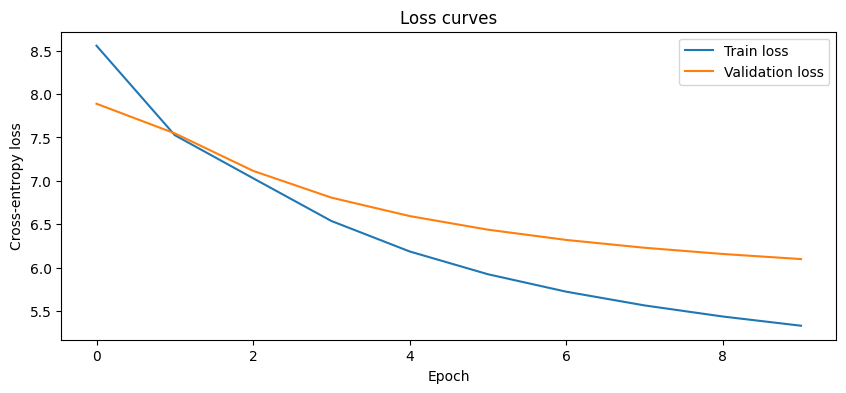

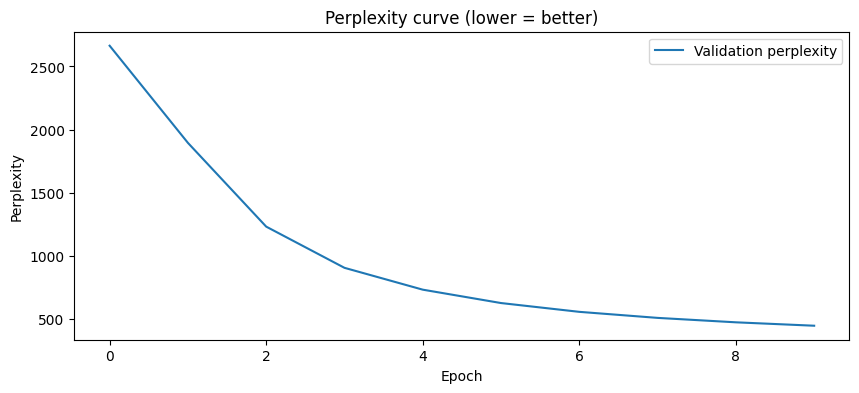

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.title("Loss curves")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history["ppl"], label="Validation perplexity")
plt.title("Perplexity curve (lower = better)")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.legend()
plt.show()



## BPE Training

In [ ]:
# history, final_val_loss, bpc, throughput_per_epoch, embedding_params  = train_model(bpe_tokenizerbpe_tokenizer, bpe_train_loader, bpe_val_loader, bpe_tokens_per_char)
history, final_val_loss, bpc, throughput_per_epoch, embedding_params  = train_model(bpe_tokenizer, bpe_train_loader, bpe_val_loader, bpe_tokens_per_char)
print("BPE Final Val Loss:", final_val_loss)

print("BPE Bits per character:", bpc)

## show throughput per epoch 
for epoch, throughput in throughput_per_epoch.items():
    print(f"Epoch {epoch}: Throughput = {throughput:.2f} tokens/second")

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.title("Loss curves")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history["ppl"], label="Validation perplexity")
plt.title("Perplexity curve (lower = better)")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.legend()
plt.show()



## Unigram Training

In [ ]:
# history, final_val_loss, bpc, throughput_per_epoch, embedding_params  = train_model(bpe_tokenizerbpe_tokenizer, bpe_train_loader, bpe_val_loader, bpe_tokens_per_char)
history, final_val_loss, bpc, throughput_per_epoch, embedding_params  = train_model(unigram_tokenizer, unigram_train_loader, unigram_val_loader, unigram_tokens_per_char)
print("BPE Final Val Loss:", final_val_loss)

print("BPE Bits per character:", bpc)

## show throughput per epoch 
for epoch, throughput in throughput_per_epoch.items():
    print(f"Epoch {epoch}: Throughput = {throughput:.2f} tokens/second")

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.title("Loss curves")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history["ppl"], label="Validation perplexity")
plt.title("Perplexity curve (lower = better)")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.legend()
plt.show()



## Wordpiece Training

In [ ]:
# history, final_val_loss, bpc, throughput_per_epoch, embedding_params  = train_model(bpe_tokenizerbpe_tokenizer, bpe_train_loader, bpe_val_loader, bpe_tokens_per_char)
history, final_val_loss, bpc, throughput_per_epoch, embedding_params  = train_model(wordpiece_tokenizer, wordpiece_train_loader, wordpiece_val_loader, wordpiece_tokens_per_char)
print("BPE Final Val Loss:", final_val_loss)

print("BPE Bits per character:", bpc)

## show throughput per epoch 
for epoch, throughput in throughput_per_epoch.items():
    print(f"Epoch {epoch}: Throughput = {throughput:.2f} tokens/second")

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.title("Loss curves")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history["ppl"], label="Validation perplexity")
plt.title("Perplexity curve (lower = better)")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.legend()
plt.show()



## Evaluation

In [ ]:
# # test loop
# with torch.no_grad():
#     model.eval()
#     test_loss = 0.0
#     count = 0

#     for x, y in test_loader:
#         x, y = x.to(device), y.to(device)
#         logits = model(x)
#         loss = criterion(logits.view(-1, vocab_size), y.view(-1))
#         test_loss += loss.item()
#         count += 1

#     avg_test_loss = test_loss / max(count, 1)
#     test_ppl = math.exp(avg_test_loss)

#     print(f"Test loss={avg_test_loss:.4f} | Test perplexity={test_ppl:.2f}")

Test loss=8.7794 | Test perplexity=6499.05


In [ ]:
# # generate a sentence

# # start_text = "In a distant future"
# start_text = "В далеком будущем"
# start_enc = tokenizer.encode(start_text)
# start_ids = torch.tensor(start_enc.ids, dtype=torch.long).unsqueeze(0)
# generated_ids = model.sample(
#     batch_size=1,
#     num_steps=50,
#     temperature=1.0,
#     start_tokens=start_ids,
#     device=device
# )
# generated_ids = generated_ids.squeeze(0).tolist()
# generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
# print("Generated text:")
# print(generated_text)


Generated text:
В да ле ком буду щем protein лю RAM проголосо вали у времен 20 тыс . Население качестве экономи ка электрон ных added 39 дев ) ства ( другими университе тами место л наиболее лению . В 1921 году ро была избра на ) . На ла . С ру мая 179 Е Р % )


### Measure Perplexity